In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt


In [74]:
exps = [
    "scream_dpxx_DYCOMSrf01_a1_1_0ps",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x10",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x15",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x20",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x25",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x30",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x5",
]

In [75]:
data = {}
for exp in exps:
    larger_path = f"/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/{exp}/run/{exp}.scream.h.INSTANT.nmins_x5.1999-*.nc"
    if exp == "scream_dpxx_DYCOMSrf01_a1_1_0ps":
        this_no = 3.33
        this_name = f"{this_no:.3g}km"
    else:
        this_no = 3.33*float(exp.split("_x")[-1])
        if this_no > 49 and this_no < 51:
            this_no = 49.9
        this_name = f"{this_no:.3g}km"
    print(f"Loading {this_name} from {larger_path}")
    data[this_name] = xr.open_mfdataset(larger_path)

Loading 3.33km from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps/run/scream_dpxx_DYCOMSrf01_a1_1_0ps.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading 33.3km from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x10/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x10.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading 49.9km from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x15/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x15.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading 66.6km from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x20/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x20.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading 83.2km from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x25/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x25.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading 99.9km from /pscratch/sd/m/mahf708/dp_sc

In [76]:
data.keys()

dict_keys(['3.33km', '33.3km', '49.9km', '66.6km', '83.2km', '99.9km', '16.6km'])

In [77]:
dfs = {}
for exp in data.keys():
    print(exp)
    dfs[exp] = data[exp][["cdnc_at_cldtop", "LiqWaterPath"]].unify_chunks().to_dataframe()

3.33km
33.3km
49.9km


66.6km
83.2km
99.9km
16.6km


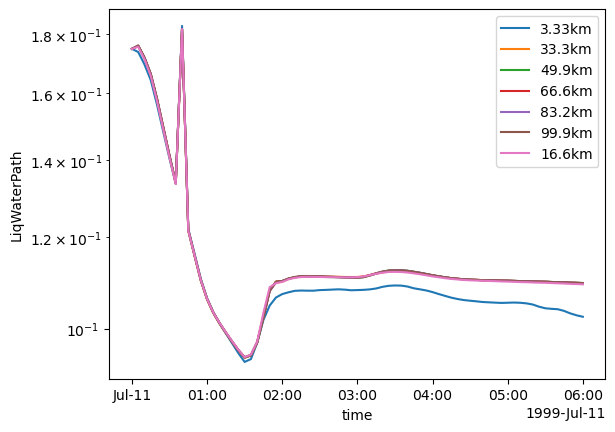

In [87]:
for exp in data.keys():
    data[exp]["LiqWaterPath"].weighted(data[exp].area).mean("ncol").plot(label=exp)
plt.yscale("log")
plt.legend()
plt.savefig("domains_lwp.png", dpi=300)

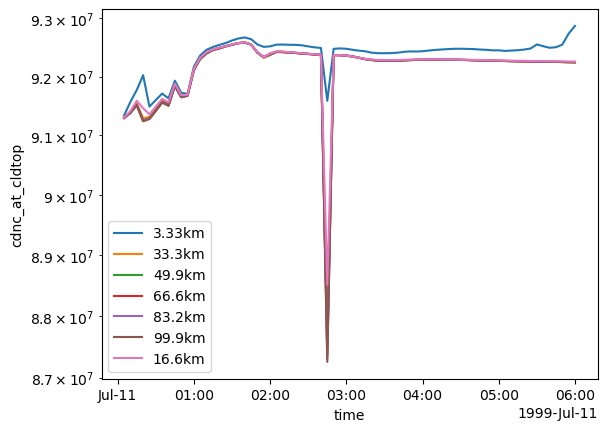

In [88]:
for exp in data.keys():
    data[exp]["cdnc_at_cldtop"].weighted(data[exp].area).mean("ncol").plot(label=exp)
plt.yscale("log")
plt.legend()
plt.savefig("domains_cdnc.png", dpi=300)

In [59]:
dfs.values()

dict_values([                          cdnc_at_cldtop  LiqWaterPath
time                ncol                              
1999-07-11 00:00:00 0                NaN      0.174806
                    1                NaN      0.174806
                    2                NaN      0.174806
                    3                NaN      0.174806
                    4                NaN      0.174806
...                                  ...           ...
1999-07-11 06:00:00 395       91531904.0      0.136776
                    396       92291056.0      0.110158
                    397       93088024.0      0.085566
                    398       92067432.0      0.117927
                    399       92682552.0      0.097773

[29200 rows x 2 columns],                           cdnc_at_cldtop  LiqWaterPath
time                ncol                              
1999-07-11 00:00:00 0                NaN      0.174806
                    1                NaN      0.174806
                    2    

In [90]:
# combine the dataframe above and ensure the labels are correct and then the index is reset
big_df = pd.concat(list(dfs.values()), keys=dfs.keys(), axis=0)
big_df["res"] = [exp for exp in dfs.keys() for _ in range(len(dfs[exp]))]
big_df.reset_index(drop=True, inplace=True)

In [84]:
big_df

,cdnc_at_cldtop,LiqWaterPath,exp
0,NaN,0.174806,3.33km
1,NaN,0.174806,3.33km
2,NaN,0.174806,3.33km
3,NaN,0.174806,3.33km
4,NaN,0.174806,3.33km
...,...,...,...
204395,92243648.0,0.109502,16.6km
204396,92242752.0,0.109476,16.6km
204397,92258072.0,0.109109,16.6km
204398,92246640.0,0.109340,16.6km


In [ ]:
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps/case_scripts/namelist_scream.xml:        <se_lx type="integer">100000</se_lx>
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x10/case_scripts/namelist_scream.xml:    <se_lx type="integer">1000000</se_lx>
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x15/case_scripts/namelist_scream.xml:    <se_lx type="integer">1500000</se_lx>
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x20/case_scripts/namelist_scream.xml:    <se_lx type="integer">2000000</se_lx>
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x25/case_scripts/namelist_scream.xml:    <se_lx type="integer">2500000</se_lx>
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x30/case_scripts/namelist_scream.xml:    <se_lx type="integer">3000000</se_lx>
/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x5/case_scripts/namelist_scream.xml:     <se_lx type="integer">500000</se_lx>

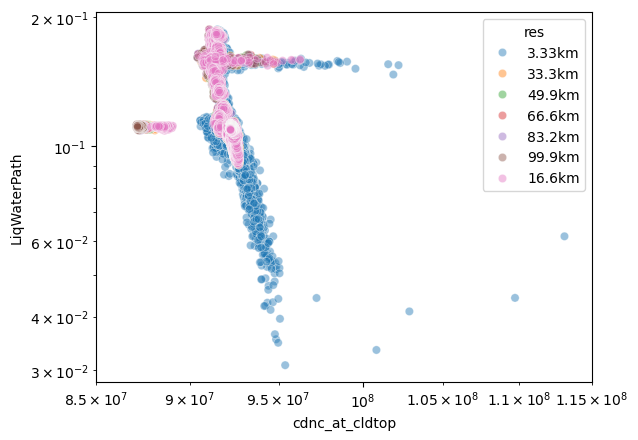

In [91]:
sns.scatterplot(
    data=big_df,
    x="cdnc_at_cldtop",
    y="LiqWaterPath",
    hue="res",
    alpha=0.45,
)
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.85e8,1.15e8)
plt.savefig("larger_domains_lwp_cdnc.png", dpi=300)

In [27]:
sns.scatterplot(
    data=big_df,
    x="cdnc_at_cldtop_larger",
    y="LiqWaterPath_larger",
    alpha=0.1,
)
plt.xscale("log")
plt.yscale("log")

ValueError: Could not interpret value `cdnc_at_cldtop_larger` for `x`. An entry with this name does not appear in `data`.

In [28]:
import glob
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.pyplot as pyplot
from cartopy import crs as crs
import cartopy.crs as ccrs
import cartopy.feature as cfeature
def fix_lon(x):
    return (x + 180) % 360 - 180

In [29]:
for exp in ["default", "larger"]:

    ds = data[exp]

    for p_var in [
        "cdnc_at_cldtop",
        "LiqWaterPath",
    ]:
        _lon, _lat, p = "lon", "lat", p_var
        vmin, vmax = ds[p].min().values, ds[p].max().values

        for i in range(ds[p].time.size):

            figure, axs = pyplot.subplots(
                1, 1,
                # subplot_kw=dict(projection=ccrs.PlateCarree()),
                figsize=(5, 5)
            )

            ax = axs
            # _ds = ds.isel(time=i).isel(lev=-1)
            # ax.set_extent([-35, -85, -60, -10], crs=ccrs.PlateCarree())


            pl = ax.tripcolor(
                ds[_lon], ds[_lat], ds[p].isel(time=i),
                # transform=crs.PlateCarree(), # cmap="BrBG",
                vmin=vmin, vmax=vmax,
                shading="gouraud"
            )
            # set title with time, convert time to datetime of format yyyy-mm-dd, HH:MM
            ax.set_title(f"DYCOMSII-RF02 {ds.time[i].values.astype('datetime64[m]').astype(str)}", fontsize=8)
            plt.colorbar(pl, ax=ax, fraction=0.046, pad=0.04, label=f"{p} ({ds[p].attrs['units']})", orientation="horizontal")
            # pl.set_norm(LogNorm(vmin=vmin, vmax=vmax))
            figure.tight_layout()
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

            # save the figure with i integer with 4 zero padding
            plt.savefig(f"gifs/{exp}_{p}_{i:04d}.png", dpi=300, bbox_inches='tight')
            # clear the frame so that we can plot a new one on the same figure next
            pyplot.close()
            print(f"{exp}_{p}_{i:04d}.png saved")
            # plt.close()

/global/u1/m/mahf708/.micromamba/envs/xgns/lib/python3.13/site-packages/xarray/core/common.py:181: RuntimeWarning: invalid value encountered in cast
  return np.array(self.values, dtype=dtype, copy=copy)


default_cdnc_at_cldtop_0000.png saved
default_cdnc_at_cldtop_0001.png saved
default_cdnc_at_cldtop_0002.png saved
default_cdnc_at_cldtop_0003.png saved
default_cdnc_at_cldtop_0004.png saved
default_cdnc_at_cldtop_0005.png saved
default_cdnc_at_cldtop_0006.png saved
default_cdnc_at_cldtop_0007.png saved
default_cdnc_at_cldtop_0008.png saved
default_cdnc_at_cldtop_0009.png saved
default_cdnc_at_cldtop_0010.png saved
default_cdnc_at_cldtop_0011.png saved
default_cdnc_at_cldtop_0012.png saved
default_cdnc_at_cldtop_0013.png saved
default_cdnc_at_cldtop_0014.png saved
default_cdnc_at_cldtop_0015.png saved
default_cdnc_at_cldtop_0016.png saved
default_cdnc_at_cldtop_0017.png saved
default_cdnc_at_cldtop_0018.png saved
default_cdnc_at_cldtop_0019.png saved
default_cdnc_at_cldtop_0020.png saved
default_cdnc_at_cldtop_0021.png saved
default_cdnc_at_cldtop_0022.png saved
default_cdnc_at_cldtop_0023.png saved
default_cdnc_at_cldtop_0024.png saved
default_cdnc_at_cldtop_0025.png saved
default_cdnc

/global/u1/m/mahf708/.micromamba/envs/xgns/lib/python3.13/site-packages/xarray/core/common.py:181: RuntimeWarning: invalid value encountered in cast
  return np.array(self.values, dtype=dtype, copy=copy)


larger_cdnc_at_cldtop_0000.png saved
larger_cdnc_at_cldtop_0001.png saved
larger_cdnc_at_cldtop_0002.png saved
larger_cdnc_at_cldtop_0003.png saved
larger_cdnc_at_cldtop_0004.png saved
larger_cdnc_at_cldtop_0005.png saved
larger_cdnc_at_cldtop_0006.png saved
larger_cdnc_at_cldtop_0007.png saved
larger_cdnc_at_cldtop_0008.png saved
larger_cdnc_at_cldtop_0009.png saved
larger_cdnc_at_cldtop_0010.png saved
larger_cdnc_at_cldtop_0011.png saved
larger_cdnc_at_cldtop_0012.png saved
larger_cdnc_at_cldtop_0013.png saved
larger_cdnc_at_cldtop_0014.png saved
larger_cdnc_at_cldtop_0015.png saved
larger_cdnc_at_cldtop_0016.png saved
larger_cdnc_at_cldtop_0017.png saved
larger_cdnc_at_cldtop_0018.png saved
larger_cdnc_at_cldtop_0019.png saved
larger_cdnc_at_cldtop_0020.png saved
larger_cdnc_at_cldtop_0021.png saved
larger_cdnc_at_cldtop_0022.png saved
larger_cdnc_at_cldtop_0023.png saved
larger_cdnc_at_cldtop_0024.png saved
larger_cdnc_at_cldtop_0025.png saved
larger_cdnc_at_cldtop_0026.png saved
l

In [30]:
import imageio

for exp in ["default", "larger"]:

    for p_var in [
        "cdnc_at_cldtop",
        "LiqWaterPath",
    ]:
        images = []
        filenames = glob.glob(f'gifs/{exp}_{p_var}_????.png')
        filenames.sort()
        for filename in filenames:
            images.append(imageio.imread(filename))
        imageio.mimsave(f'{exp}_{p_var}.gif', images, loop=0)

/tmp/ipykernel_711695/93929509.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))
